```
"Understanding Deep Learning Requires Rethinking Generalization" by Zhang, Bengio, Hardt, Recht, and Vinyals, published at ICLR 2017.
```
https://arxiv.org/pdf/1611.03530

1. Background:
- ImageNet is most famous image classification dataset https://www.image-net.org/
- Contains ImageNet-1K contains 1000 classes , 130GB
- 1,281,167 Training, 50,000 Validation and 100,000 Test Images

1. Summary of the paper:
    - Authors show that shuffeling around the labels a neural network can still perform well on the training dataset

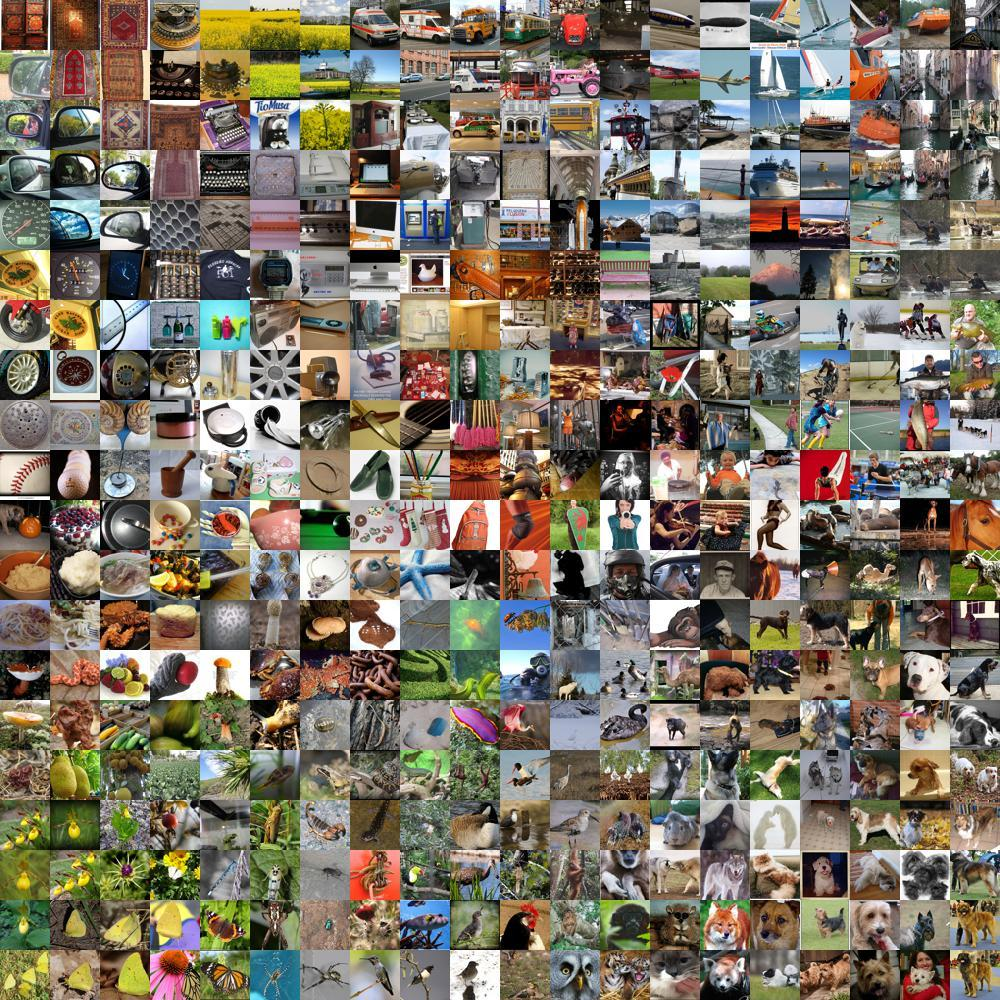

##  Training a network using MSE
https://pytorch.org/docs/stable/index.html

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Tuple, Optional

In [ ]:
# Creating a dataset and understanding what we are working with. 
DATASET_SIZE: int = 1000

mode = "input_high_dim"

if mode == "linear":
    INPUT_DIM: int = 1
    OUTPUT_DIM: int = 1
    x = torch.linspace(0, 1, DATASET_SIZE).reshape(-1, INPUT_DIM)
    y = torch.linspace(1, 0, DATASET_SIZE).reshape(-1, OUTPUT_DIM)

elif mode == "output_random":
    INPUT_DIM: int = 1
    OUTPUT_DIM: int = 1
    x = torch.linspace(0, 1, DATASET_SIZE).reshape(-1, INPUT_DIM)
    y = torch.rand((DATASET_SIZE, OUTPUT_DIM))

elif mode == "input_high_dim":
    INPUT_DIM: int = 256
    OUTPUT_DIM: int = 1
    x = torch.rand((DATASET_SIZE, INPUT_DIM))
    y = torch.rand((DATASET_SIZE, OUTPUT_DIM))

In [ ]:
# Visualize the dataset
def visualized(x, y, y_pred, title):
    # Create a figure with 2 subplots side by side
    if y_pred is not None:
        fig, axs = plt.subplots(1, 3, figsize=(12, 5))
    else:   
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))


    if x.shape[1] == 1:
        plot_x = x.repeat(1,100)
    else:
        plot_x = x

    # Plot input data
    im1 = axs[0].imshow(plot_x, cmap='viridis')
    axs[0].set_ylabel('Input Value (x)')
    fig.colorbar(im1, ax=axs[0])

    # Plot target/prediction data
    im2 = axs[1].imshow(y.repeat(1,100), cmap='viridis')
    axs[1].set_ylabel('Output Value (y)')
    fig.colorbar(im2, ax=axs[1])

    if y_pred is not None:
        im3 = axs[2].imshow(y_pred.repeat(1,100), cmap='viridis')
        axs[2].set_ylabel('Prediction Value (y)')
        fig.colorbar(im3, ax=axs[2])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

visualized(x,y, None, "Dataset Visualization")

# Jonas: Show the random dataset alternative

In [ ]:
HIDDEN_DIM: int = 12
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        """
        Initialize a 2-layer MLP.
        
        Args:
            input_dim (int): Dimension of input features
            hidden_dim (int): Dimension of hidden layer
            output_dim (int): Dimension of output
        """
        super(MLP, self).__init__()
        
        # First layer: input_dim -> hidden_dim with ReLU activation
        self.layer1: nn.Linear = nn.Linear(input_dim, hidden_dim)
        self.activation: nn.ReLU = nn.ReLU()
        
        # Second layer: hidden_dim -> output_dim
        self.layer2: nn.Linear = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the network.
        Args:
            x (torch.Tensor, dim=(BS, input_dim), dtype=float32): Input tensor
        Returns:
            y_head ( torch.Tensor, dim=(BS, output_dim), dtype=float32): Output tensor
        """
        # Pass input through first layer and activation function
        x = self.activation(self.layer1(x))
        
        # Pass through second layer
        y_head = self.layer2(x)
        
        return y_head
    
# Notes for Jonas:
# Which values can the network predict?
        

In [ ]:
# torch.manual_seed(42)

model = MLP(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM)
print(f"Model architecture:\n{model}")

# Define loss function and optimizer
criterion: nn.MSELoss = nn.MSELoss()
optimizer: optim.Adam = optim.Adam(model.parameters(), lr=LEARNING_RATE)

losses: List[float] = []

def eval_model(model, criterion, x, y):
    model.eval()
    with torch.no_grad():
        y_pred: torch.Tensor = model(x)
        loss = criterion(y_pred, y).item()
    
    visualized(x, y, y_pred, "Model Predictions")
    print(f"Final loss: {loss:.4f}")
    model.train()

eval_model(model, criterion, x, y)

# Notes for Jonas
# 1. Run this cell multiple times and explain initalization
# 2. Output range dependent on architecture and activation functions

In [ ]:
LEARNING_RATE: float = 0.001
NUM_EPOCHS: int = 10000

for epoch in range(NUM_EPOCHS):
    # Forward pass
    y_pred: torch.Tensor = model(x)
    
    # Compute loss
    loss: torch.Tensor = criterion(y_pred, y)
    
    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Store loss
    losses.append(loss.item())
    
    # Print progress
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {loss.item():.4f}')

# Jonas: show when random output importance of tuning learning rate

In [ ]:
eval_model(model, criterion, x, y)
# Jonas notes - > runs ame experiment with random dataset
# Step 2 set vmin=0, vmax=1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Generate 1D data points
predictions = torch.linspace(-5, 5, 100)

# Calculate MSE for y=0 and y=1
y_0_loss = torch.nn.functional.mse_loss(predictions, torch.zeros_like(predictions), reduction='none')
y_1_loss = torch.nn.functional.mse_loss(predictions, torch.ones_like(predictions), reduction='none')

# Plot the data points and MSE
plt.figure(figsize=(10, 6))
plt.plot(predictions.numpy(), y_0_loss.numpy(), label='MSE for y=0')
plt.plot(predictions.numpy(), y_1_loss.numpy(), label='MSE for y=1')

plt.title('Mean Squared Error Visualized')
plt.xlabel('y_pred')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# What would happen if we run the same on ImageNet ?